# Getting Started: Bayesian Workflow with ProbPipe

This tutorial walks through an iterative Bayesian modeling workflow using ProbPipe, following the principles outlined in [Bayesian Workflow](https://arxiv.org/abs/2011.01808) (Gelman et al., 2020). The key idea is that applied Bayesian analysis is *iterative*: we start with a simple model, check it against data, revise, and repeat.

### ProbPipe's approach

Most workflows for probabilistic inference can be described in terms of four **abstract components**:

1. **Distributions** — priors, posteriors, data products.
2. **Fixed inputs** — data and hyperparameters.
3. **Operations** that transform distributions — conditioning, pushforwards, expectations.
4. **Differentiation** with respect to fixed inputs.

Implementing these workflows, however, is harder than describing them:

- **Algorithmic challenges** — many possible algorithms exist for the same operation. A posterior could be approximated using different MCMC algorithms, variational inference, or sequential Monte Carlo. These are implemented across many packages and often not designed to be directly compatible.
- **Representational challenges** — algorithms require or output specific distribution formats that may not be compatible with other parts of the workflow. For example, MCMC outputs a discrete approximation to a distribution, but many MCMC algorithms require continuous parametric priors.

ProbPipe manages representations and algorithms automatically by default, while giving you control over these choices when you want it:

- **`Distribution`s** support subsets of capabilities via protocols (`SupportsSampling`, `SupportsLogProb`, ...) — ProbPipe converts between representations as needed, or you can choose a specific representation explicitly.
- **`WorkflowFunction`s** compute pushforward distributions automatically — you write a function that takes fixed values, and ProbPipe propagates uncertainty when those values are in fact unknown.
- **`condition_on`** selects an appropriate inference algorithm automatically, but you can specify the algorithm, backend, or tuning parameters directly.
- **`predictive_check`** provides built-in prior and posterior predictive checking.

### The dataset

We use the **horseshoe crab satellite** dataset (Brockmann, 1996; Agresti, 2007). Each nesting female horseshoe crab may attract "satellite" males. The response is the **count of satellites**, with the female's **carapace width** (cm) as the primary covariate.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype.*float64.*")

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
import tensorflow_probability.substrates.jax.glm as tfp_glm

from probpipe import (
    MultivariateNormal, EmpiricalDistribution, BootstrapReplicateDistribution,
    GLMLikelihood, SimpleModel,
    condition_on, from_distribution, sample, mean, variance,
    workflow_function, predictive_check, provenance_ancestors,
)
from probpipe.modeling import IncrementalConditioner

# -- Horseshoe crab data (Brockmann 1996, Agresti 2007) --
_raw = np.array([
    [28.3, 8], [22.5, 0], [26.0, 9], [24.8, 0], [26.0, 4], [23.8, 0],
    [26.5, 0], [24.7, 0], [23.7, 0], [25.6, 0], [24.3, 0], [25.8, 0],
    [28.2,11], [21.0, 0], [26.0,14], [27.1, 8], [25.2, 1], [29.0, 1],
    [24.7, 0], [27.4, 5], [23.2, 4], [25.0, 3], [22.5, 1], [26.7, 2],
    [25.8, 3], [26.2, 0], [28.7, 3], [26.8, 5], [27.5, 0], [24.9, 0],
    [29.3, 4], [25.8, 0], [25.7, 0], [25.7, 8], [26.7, 5], [23.7, 0],
    [26.8, 0], [27.5, 6], [23.4, 0], [27.9, 6], [27.5, 3], [26.1, 5],
    [27.7, 6], [30.0, 5], [28.5, 9], [28.9, 4], [28.2, 6], [25.0, 4],
    [28.5, 3], [30.3, 3], [24.7, 5], [27.7, 5], [27.4, 6], [22.9, 4],
    [25.7, 5], [28.3,15], [27.2, 3], [26.2, 3], [27.8, 0], [25.5, 0],
    [27.1, 0], [24.5, 5], [27.0, 3], [26.0, 5], [28.0, 1], [30.0, 8],
    [29.0,10], [26.2, 0], [26.5, 0], [26.2, 3], [25.6, 7], [23.0, 1],
    [23.0, 0], [25.4, 6], [24.2, 0], [22.9, 0], [26.0, 3], [25.4, 4],
    [25.7, 0], [25.1, 5], [24.5, 0], [27.5, 0], [23.1, 0], [25.9, 4],
    [25.8, 0], [27.0, 3], [28.5, 0], [25.5, 0], [23.5, 0], [24.0, 0],
    [29.7, 5], [26.8, 0], [26.7, 0], [28.7, 0], [23.1, 0], [29.0, 1],
    [25.5, 0], [26.5, 1], [24.5, 1], [28.5, 1], [28.2, 1], [24.5, 1],
    [27.5, 1], [24.7, 4], [25.2, 1], [27.3, 1], [26.3, 1], [29.0, 1],
    [25.3, 2], [26.5, 4], [27.8, 3], [27.0, 6], [25.7, 0], [25.0, 2],
    [31.9, 2], [23.7, 0], [29.3,12], [22.0, 0], [25.0, 5], [27.0, 6],
    [23.8, 6], [30.2, 2], [26.2, 0], [24.2, 2], [27.4, 3], [25.4, 0],
    [28.4, 3], [22.5, 4], [26.2, 2], [24.9, 6], [24.5, 6], [25.1, 0],
    [28.0, 4], [25.8,10], [27.9, 7], [24.9, 0], [28.4, 5], [27.2, 5],
    [25.0, 6], [27.5, 6], [33.5, 7], [30.5, 3], [29.0, 3], [24.3, 0],
    [25.8, 0], [25.0, 8], [31.7, 4], [29.5, 4], [24.0,10], [30.0, 9],
    [27.6, 4], [26.2, 0], [23.1, 0], [22.9, 0], [24.5, 0], [24.7, 4],
    [28.3, 0], [23.9, 2], [23.8, 0], [29.8, 4], [26.5, 4], [26.0, 3],
    [28.2, 8], [25.7, 0], [26.5, 7], [25.8, 0], [24.1, 0], [26.2, 2],
    [26.1, 3], [29.0, 4], [28.0, 0], [27.0, 0], [24.5, 0],
], dtype=np.float32)

x_width, y_sat = _raw[:, 0], _raw[:, 1]
x_mean, x_std = float(x_width.mean()), float(x_width.std())
x_std_ized = (x_width - x_mean) / x_std

# Design matrix: intercept + standardized width
X = np.column_stack([np.ones_like(x_std_ized), x_std_ized]).astype(np.float32)

print(f"n = {len(y_sat)} crabs, "
      f"mean = {y_sat.mean():.2f}, var = {y_sat.var():.2f}, "
      f"zeros = {int(np.sum(y_sat == 0))}/{len(y_sat)}")

n = 173 crabs, mean = 2.92, var = 9.85, zeros = 62/173


## 1. Choose an initial model

We start simple: a **Poisson regression** for count data, $y_i \sim \text{Poisson}(\exp(\boldsymbol{x}_i^\top \boldsymbol{\beta}))$.

`GLMLikelihood` wraps a TFP GLM family and a design matrix into a ProbPipe likelihood that supports both inference and data generation. Models can also be defined using PyMC, Stan, or TFP directly (see §11).

In [2]:
lik_poisson = GLMLikelihood(tfp_glm.Poisson(), X)
prior = MultivariateNormal(loc=jnp.zeros(2), cov=5.0 * jnp.eye(2), name="prior")
model_poisson = SimpleModel(prior, lik_poisson, name="poisson")

## 2. Prior predictive checking

Before fitting, we check whether the prior implies plausible data. `predictive_check` draws parameters from the prior, generates replicated data, and computes a summary statistic. Without `observed_data`, it acts as a **prior predictive check**.

In [3]:
prior_check = predictive_check(
    prior, lik_poisson, test_fn=lambda d: float(jnp.mean(d)),
    n_samples=len(y_sat), n_replications=200, key=jax.random.PRNGKey(0),
)
prior_means = np.array(prior_check["replicated_statistics"].samples)
print(f"Prior predictive mean: median={np.median(prior_means):.1f}, "
      f"90th pct={np.percentile(prior_means, 90):.1f}")
print(f"Observed mean: {y_sat.mean():.2f}")

Prior predictive mean: median=3.6, 90th pct=566.2
Observed mean: 2.92


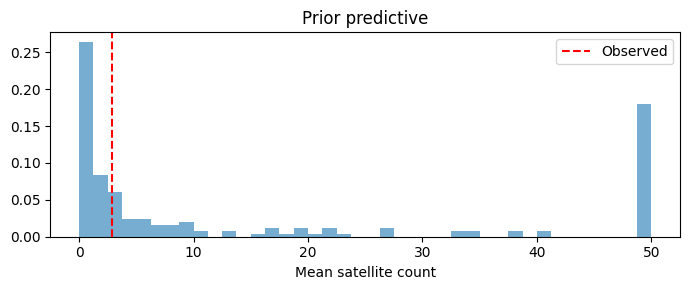

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.clip(prior_means, 0, 50), bins=40, density=True, alpha=0.6)
ax.axvline(y_sat.mean(), color="red", ls="--", label="Observed")
ax.set(xlabel="Mean satellite count", title="Prior predictive"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Fit the model

`condition_on` runs MCMC — NUTS when the log-density is JAX-traceable, gradient-free RWMH otherwise. The result is an `MCMCApproximateDistribution` with chain structure and diagnostics.

In [5]:
posterior_poisson = condition_on(
    model_poisson, jnp.asarray(y_sat),
    num_results=2000, num_warmup=1000, random_seed=0,
)
print(f"Posterior mean: {mean(posterior_poisson)}")
print(posterior_poisson.diagnostics)

Posterior mean: [1.0078306  0.34519282]
InferenceDiagnostics(algorithm=nuts, accept_rate=0.893, final_step_size=0.0508)


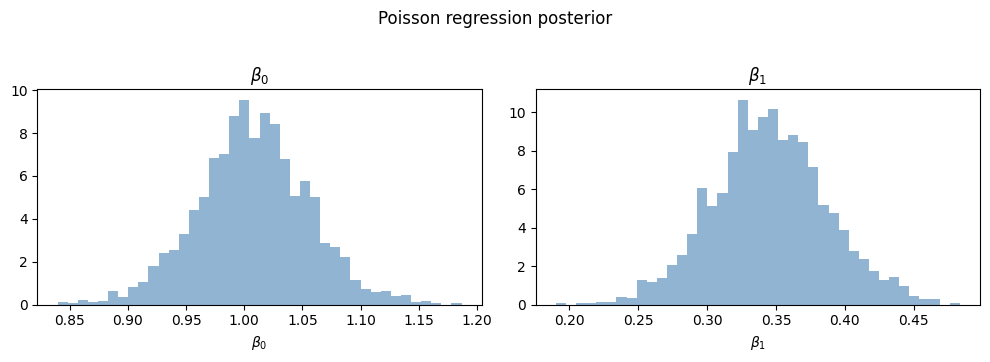

In [6]:
draws = np.array(posterior_poisson.draws())
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, j, name in zip(axes, range(2), [r"$\beta_0$", r"$\beta_1$"]):
    ax.hist(draws[:, j], bins=40, density=True, alpha=0.6, color="steelblue")
    ax.set(xlabel=name, title=name)
plt.suptitle("Poisson regression posterior", y=1.02)
plt.tight_layout(); plt.show()

## 4. Posterior predictive checking

Does the fitted model reproduce key features of the data? With `observed_data`, `predictive_check` also returns a calibration **p-value**. A key diagnostic for count data is the **variance-to-mean ratio** — equal to 1 for Poisson, greater than 1 for overdispersed data.

In [7]:
var_mean_ratio = lambda d: float(jnp.var(d) / jnp.maximum(jnp.mean(d), 1e-6))
zero_fraction = lambda d: float(jnp.mean(d == 0))

ppc_vmr = predictive_check(
    posterior_poisson, lik_poisson, test_fn=var_mean_ratio,
    observed_data=jnp.asarray(y_sat), n_replications=500, key=jax.random.PRNGKey(1),
)
ppc_zeros = predictive_check(
    posterior_poisson, lik_poisson, test_fn=zero_fraction,
    observed_data=jnp.asarray(y_sat), n_replications=500, key=jax.random.PRNGKey(2),
)
print(f"Var/mean ratio — observed: {ppc_vmr["observed_statistic"]:.2f}, p={ppc_vmr["p_value"]:.3f}")
print(f"Zero fraction  — observed: {ppc_zeros["observed_statistic"]:.2f}, p={ppc_zeros["p_value"]:.3f}")

Var/mean ratio — observed: 3.38, p=0.000
Zero fraction  — observed: 0.36, p=0.000


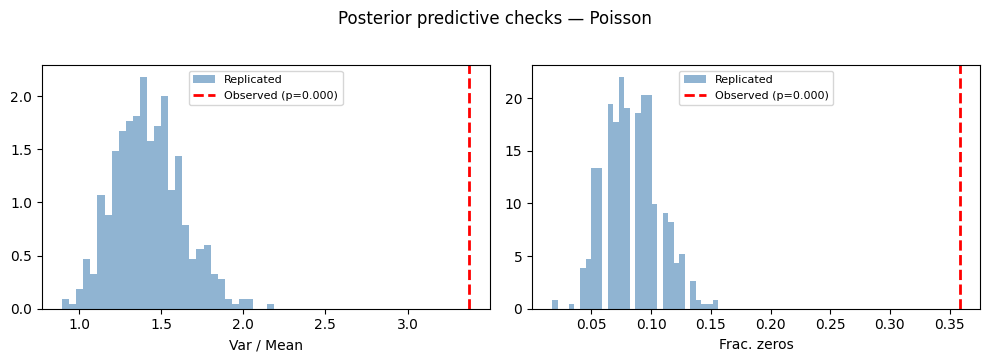

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, check, label in zip(axes, [ppc_vmr, ppc_zeros], ["Var / Mean", "Frac. zeros"]):
    ax.hist(np.array(check["replicated_statistics"].samples), bins=30,
            density=True, alpha=0.6, color="steelblue", label="Replicated")
    ax.axvline(check["observed_statistic"], color="red", ls="--", lw=2,
               label=f"Observed (p={check["p_value"]:.3f})")
    ax.set(xlabel=label); ax.legend(fontsize=8)
plt.suptitle("Posterior predictive checks — Poisson", y=1.02)
plt.tight_layout(); plt.show()

The variance-to-mean ratio check **fails** — the observed data are far more overdispersed than the Poisson model can produce. This motivates revising the model.

## 5. Revise the model — swap the likelihood

The **negative binomial** naturally handles overdispersion. With `GLMLikelihood`, swapping is a one-line change — just replace the TFP family.

In [9]:
lik_nb = GLMLikelihood(tfp_glm.NegativeBinomial(), X)
prior_nb = MultivariateNormal(loc=jnp.zeros(2), cov=5.0 * jnp.eye(2), name="prior_nb")
model_nb = SimpleModel(prior_nb, lik_nb, name="negbin")

posterior_nb = condition_on(
    model_nb, jnp.asarray(y_sat),
    num_results=2000, num_warmup=1000, random_seed=1,
)
print(f"NegBin posterior mean: {mean(posterior_nb)}")
print(posterior_nb.diagnostics)

ppc_nb = predictive_check(
    posterior_nb, lik_nb, test_fn=var_mean_ratio,
    observed_data=jnp.asarray(y_sat), n_replications=500, key=jax.random.PRNGKey(3),
)
print(f"\nVar/mean p-value: {ppc_nb["p_value"]:.3f} (was {ppc_vmr["p_value"]:.3f} for Poisson)")

NegBin posterior mean: [0.99762714 0.40174055]
InferenceDiagnostics(algorithm=nuts, accept_rate=0.901, final_step_size=0.1157)



Var/mean p-value: 0.944 (was 0.000 for Poisson)


## 6. Compare models

Same pipeline, different likelihood — overlay the posteriors to compare.

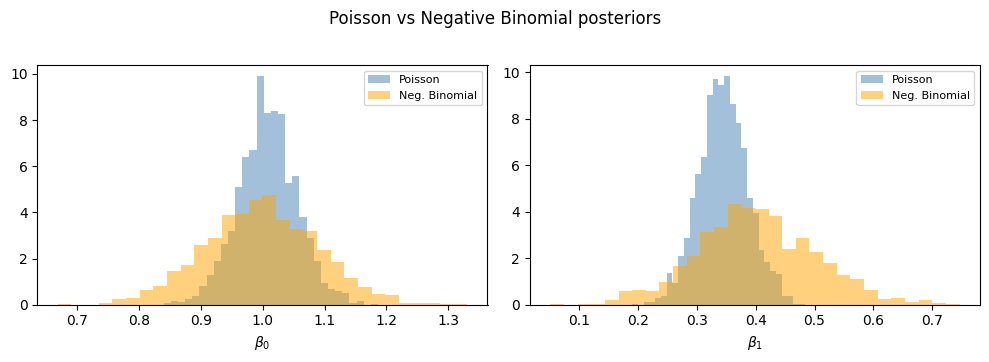

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, j, name in zip(axes, range(2), [r"$\beta_0$", r"$\beta_1$"]):
    ax.hist(np.array(posterior_poisson.draws()[:, j]), bins=30, density=True,
            alpha=0.5, color="steelblue", label="Poisson")
    ax.hist(np.array(posterior_nb.draws()[:, j]), bins=30, density=True,
            alpha=0.5, color="orange", label="Neg. Binomial")
    ax.set(xlabel=name); ax.legend(fontsize=8)
plt.suptitle("Poisson vs Negative Binomial posteriors", y=1.02)
plt.tight_layout(); plt.show()

## 7. Bagged posteriors

Under model misspecification, standard posteriors can be unreliable across datasets. The **bagged posterior** ([Huggins & Miller, 2024](https://doi.org/10.1214/24-EJS2237)) averages over posteriors conditioned on bootstrapped datasets. `BootstrapReplicateDistribution` wraps the data as a distribution over bootstrap datasets, and broadcasting `condition_on` over it produces the bagged posterior.

In [11]:
bootstrap_data = BootstrapReplicateDistribution(EmpiricalDistribution(jnp.asarray(y_sat)))
bagged = condition_on(model_nb, bootstrap_data, num_results=500, num_warmup=300, random_seed=42)
print(f"Bootstrap components: {len(bagged.components)}")

Bootstrap components: 128


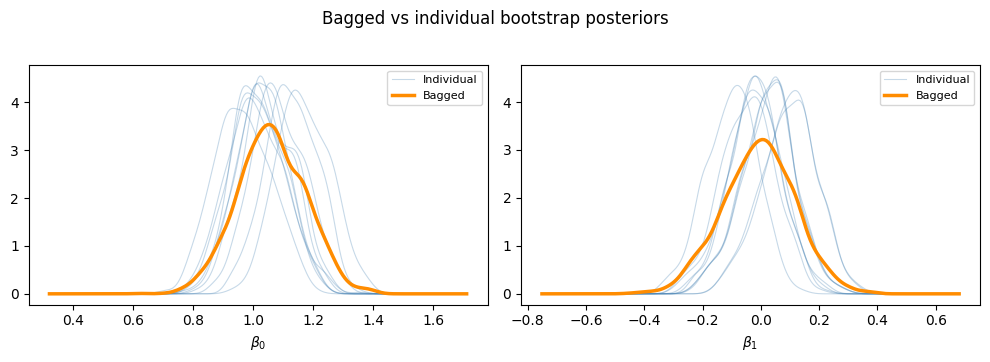

In [12]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, j, name in zip(axes, range(2), [r"$\beta_0$", r"$\beta_1$"]):
    for i, post in enumerate(bagged.components[:10]):
        d = np.array(post.samples[:, j])
        xs = np.linspace(d.min() - 0.3, d.max() + 0.3, 200)
        ax.plot(xs, gaussian_kde(d)(xs), alpha=0.3, lw=0.8, color="steelblue",
                label="Individual" if i == 0 else None)
    bd = np.array(sample(bagged, sample_shape=(2000,), key=jax.random.PRNGKey(99))[:, j])
    xs = np.linspace(bd.min() - 0.3, bd.max() + 0.3, 200)
    ax.plot(xs, gaussian_kde(bd)(xs), color="darkorange", lw=2.5, label="Bagged")
    ax.set(xlabel=name); ax.legend(fontsize=8)
plt.suptitle("Bagged vs individual bootstrap posteriors", y=1.02)
plt.tight_layout(); plt.show()

## 8. Sequential updating

`IncrementalConditioner` chains posterior updates across data batches. Since MCMC needs a parametric prior, `from_distribution` converts the empirical posterior to a `MultivariateNormal` via moment matching.

In [13]:
n0 = 80
post0 = condition_on(
    SimpleModel(prior_nb, GLMLikelihood(tfp_glm.NegativeBinomial(), X[:n0])),
    jnp.asarray(y_sat[:n0]), num_results=1000, num_warmup=500, random_seed=10,
)
approx = from_distribution(post0, MultivariateNormal, name="approx")

def condition_fn(model, data):
    p = model._condition_on(data, num_results=500, num_warmup=300, random_seed=0)
    return from_distribution(p, MultivariateNormal, name="posterior")

conditioner = IncrementalConditioner(
    prior=approx,
    likelihood=GLMLikelihood(tfp_glm.NegativeBinomial(), X[80:130]),
    condition_fn=condition_fn,
)

total = n0
for s, e in [(80, 130), (130, len(y_sat))]:
    conditioner._likelihood = GLMLikelihood(tfp_glm.NegativeBinomial(), X[s:e])
    post = conditioner.update(data=jnp.asarray(y_sat[s:e]))
    total += e - s
    print(f"n={total}: mean = {mean(post)}")

n=130: mean = [0.98358214 0.45347896]


n=173: mean = [1.0135045  0.39267838]


## 9. Propagate uncertainty

A `@workflow_function` that takes fixed values will automatically propagate uncertainty when those values are in fact unknown (i.e., represented as distributions).

In [14]:
@workflow_function
def predict_rate(params, x):
    return jnp.exp(params[0] + params[1] * x)

rate_dist = predict_rate(params=posterior_nb, x=0.0)
print(f"Rate at mean width: {float(mean(rate_dist)):.2f} "
      f"(+/- {float(jnp.sqrt(variance(rate_dist))):.2f})")

Rate at mean width: 2.71 (+/- 0.26)


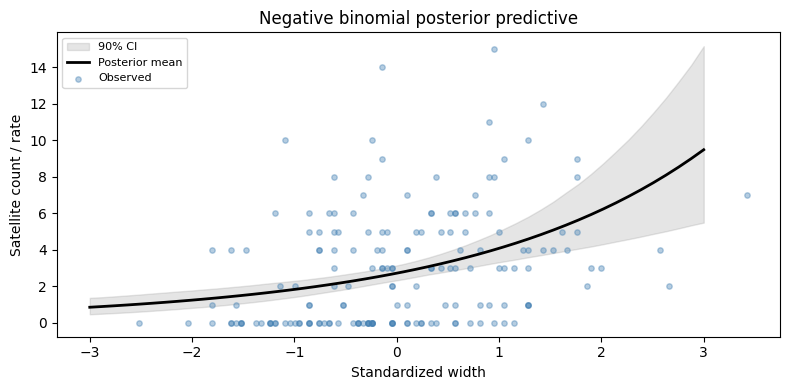

In [15]:
x_grid = jnp.linspace(-3, 3, 50)
D = np.array(posterior_nb.draws())
rates = np.exp(D[:, 0:1] + D[:, 1:2] * np.array(x_grid)[None, :])
lo, hi = np.percentile(rates, [5, 95], axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_grid, lo, hi, alpha=0.2, color="gray", label="90% CI")
ax.plot(x_grid, rates.mean(axis=0), "k-", lw=2, label="Posterior mean")
ax.scatter(x_std_ized, y_sat, s=15, alpha=0.4, color="steelblue", label="Observed")
ax.set(xlabel="Standardized width", ylabel="Satellite count / rate",
       title="Negative binomial posterior predictive")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10. Provenance tracking

Every distribution records how it was created — the algorithm, parents, and metadata.

In [16]:
print(posterior_nb.source)
print(f"Ancestors: {[type(a).__name__ for a in provenance_ancestors(posterior_nb)]}")

Provenance('nuts', parents=[prior_nb])
Ancestors: ['MultivariateNormal']


## 11. External model-building tools

The same `condition_on` interface works with models defined in other frameworks:



In all cases the result is an `MCMCApproximateDistribution` that plugs into the same downstream workflow.

## 12. Summary

| Step | ProbPipe Feature |
|---|---|
| Define model | `GLMLikelihood` + `SimpleModel` (or PyMC/Stan) |
| Prior predictive check | `predictive_check(prior, ...)` |
| Fit | `condition_on(model, data)` |
| Diagnostics | `posterior.diagnostics` |
| Posterior predictive check | `predictive_check(posterior, ..., observed_data=...)` |
| Revise model | Swap the TFP family, rebuild `SimpleModel` |
| Compare models | Same pipeline, different likelihoods |
| Bagged posteriors | `BootstrapReplicateDistribution` + broadcasting |
| Sequential updating | `IncrementalConditioner` + `from_distribution` |
| Propagate uncertainty | `@workflow_function` broadcasting |
| External tools | `PyMCModel`, `StanModel`, `condition_on_nutpie` |
| Provenance | `posterior.source`, `provenance_ancestors` |

### References

- Gelman, A., Vehtari, A., Simpson, D., et al. (2020). [Bayesian Workflow](https://arxiv.org/abs/2011.01808). *arXiv:2011.01808*.
- Brockmann, H.J. (1996). Satellite male groups in horseshoe crabs, *Limulus polyphemus*. *Ethology*, 102(1), 1–21.
- Huggins, J.H. & Miller, J.W. (2024). [Reproducible Model Selection Using Bagged Posteriors](https://doi.org/10.1214/24-EJS2237). *Electronic Journal of Statistics*.

### Next steps

- [API Reference](../api/distributions.md)
- [Reference Notebooks](../reference_notebooks.md)